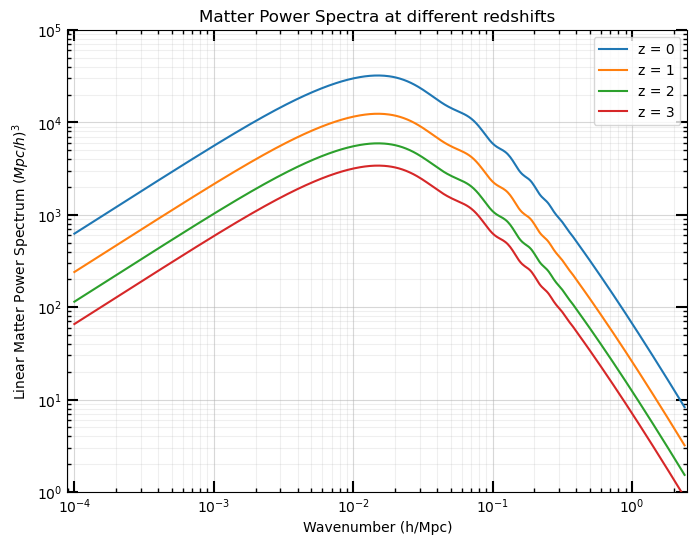

In [1]:
from cosmology_amilly.power_spectrum import Power_Spectrum
import matplotlib.pyplot as plt

k = []
P = []
plt.figure(figsize=(8, 6))


k_0 = Power_Spectrum(0, "test_data_source/camb_0.dat").k_vals
P_0 = Power_Spectrum(0, "test_data_source/camb_0.dat").Pk_interp(k_0)

k_1 = Power_Spectrum(1, "test_data_source/camb_1.dat").k_vals
P_1 = Power_Spectrum(1, "test_data_source/camb_1.dat").Pk_interp(k_1)

k_2 = Power_Spectrum(2, "test_data_source/camb_2.dat").k_vals
P_2 = Power_Spectrum(2, "test_data_source/camb_2.dat").Pk_interp(k_2)

k_3 = Power_Spectrum(3, "test_data_source/camb_3.dat").k_vals
P_3 = Power_Spectrum(3, "test_data_source/camb_3.dat").Pk_interp(k_3)

k = [k_0, k_1, k_2, k_3]
P = [P_0, P_1, P_2, P_3]

for i in range(4):
    plt.plot(k[i], P[i], label=r"z = " + str(i))

plt.grid(True)
plt.xscale("log")
plt.yscale("log")
plt.title("Matter Power Spectra at different redshifts")
plt.legend()
plt.xlim(10 ** (-4.05), 2.5)
plt.ylim(1, 10**5)


plt.tick_params(axis="both", direction="in", length=8, width=1.5, top=True, right=True)
plt.tick_params(which="minor", direction="in", length=3, width=1, top=True, right=True)
plt.grid(which="major", alpha=0.5)
plt.grid(which="minor", alpha=0.2)
plt.xlabel("Wavenumber (h/Mpc)")
plt.ylabel("Linear Matter Power Spectrum $(Mpc/h)^3$")

plt.savefig("P_k_redshift.pdf")
plt.show()

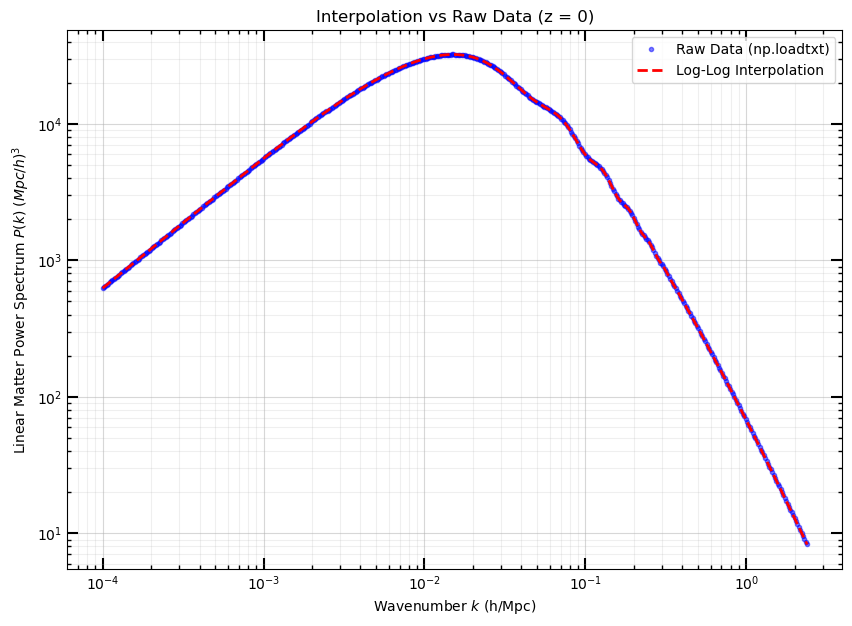

In [6]:
import numpy as np

plt.figure(figsize=(10, 7))

ps_0 = Power_Spectrum(0, "test_data_source/camb_0.dat")

k_raw = ps_0.k_vals
P_raw = ps_0.P_vals

k_dense = np.logspace(np.log10(k_raw[0]), np.log10(k_raw[-1]), 1000)
P_interp = ps_0.Pk_interp(k_dense)

plt.plot(k_raw, P_raw, 'o', color='blue', alpha=0.5, markersize=3, label='Raw Data (np.loadtxt)')

plt.plot(k_dense, P_interp, '--', color='red', linewidth=2, label='Log-Log Interpolation')

plt.xscale("log")
plt.yscale("log")
plt.title("Interpolation vs Raw Data (z = 0)")
plt.legend()

plt.tick_params(axis="both", direction="in", length=8, width=1.5, top=True, right=True)
plt.tick_params(which="minor", direction="in", length=3, width=1, top=True, right=True)
plt.grid(which="major", alpha=0.5)
plt.grid(which="minor", alpha=0.2)
plt.xlabel("Wavenumber $k$ (h/Mpc)")
plt.ylabel("Linear Matter Power Spectrum $P(k)$ $(Mpc/h)^3$")

plt.show()